In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import esc_fresnel
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel import utils, props
import esc_fresnel.esc_fresnel_subap as esc
import esc_fresnel.esc_optics as esc_optics

/home/kianmilani/miniconda3/envs/km311env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
2025-05-12 09:27:14,146	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [8]:
D = 10e-3
wl = 500e-9

z = 10*wl
Nf = (D/2)**2 / (wl * z)
print(Nf)

# Nf = 1000
# z = (D/2)**2 / (wl * Nf)
# print(z)


10000000.000000002


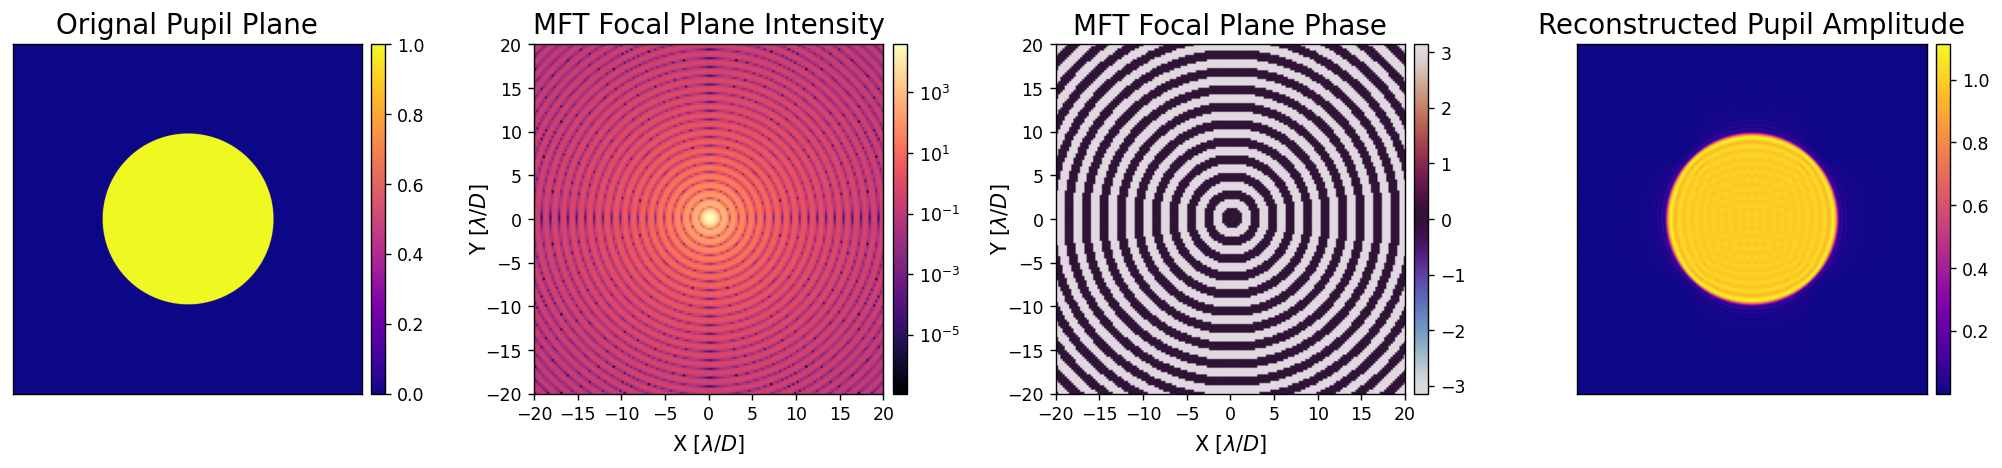

In [2]:
reload(utils)

diam = 10*u.mm
npix = 1000
oversample = 2.048
nfp = 160
fp_pxscl = 1/4

pwf = poppy.FresnelWavefront(beam_radius=diam/2, npix=npix, oversample=oversample)
ap = poppy.CircularAperture(radius=diam/2, ).get_transmission(pwf)

fpwf_mft = props.mft_forward(ap, npix=npix, npsf=nfp, psf_pixelscale_lamD=fp_pxscl, convention='-', pp_centering='odd')
fp_int = xp.abs(fpwf_mft)**2
fp_phs = xp.angle(fpwf_mft)

reconstructed_pupil = xp.abs(props.mft_reverse(fpwf_mft, psf_pixelscale_lamD=fp_pxscl, npix=npix, N=2048, convention='+', pp_centering='odd'))

fp_ext = 20
fp_ticks = np.arange(-fp_ext, fp_ext + 0.01, 5)

utils.imshow(
    [ap, fp_int, fp_phs, reconstructed_pupil],
    titles=['Orignal Pupil Plane', 'MFT Focal Plane Intensity', 'MFT Focal Plane Phase', 'Reconstructed Pupil Amplitude'],
    title_fzs=[16]*4,
    xticks=[[], fp_ticks, fp_ticks, []],
    yticks=[[], fp_ticks, fp_ticks, []],
    pxscls=[1, fp_pxscl, fp_pxscl, 1],
    xlabels=[None, 'X [$\lambda/D$]', 'X [$\lambda/D$]', None],
    ylabels=[None, 'Y [$\lambda/D$]', 'Y [$\lambda/D$]', None],
    xlabel_pads=[None, 5, 5, None],
    ylabel_pads=[None, -3, -3, None],
    label_fzs=[None, 12, 12, None],
    norms=[None, LogNorm(), None],
    cmaps=['plasma', 'magma', 'twilight', 'plasma'],
    wspace=0.4,
    figsize=(20,5),
)

1


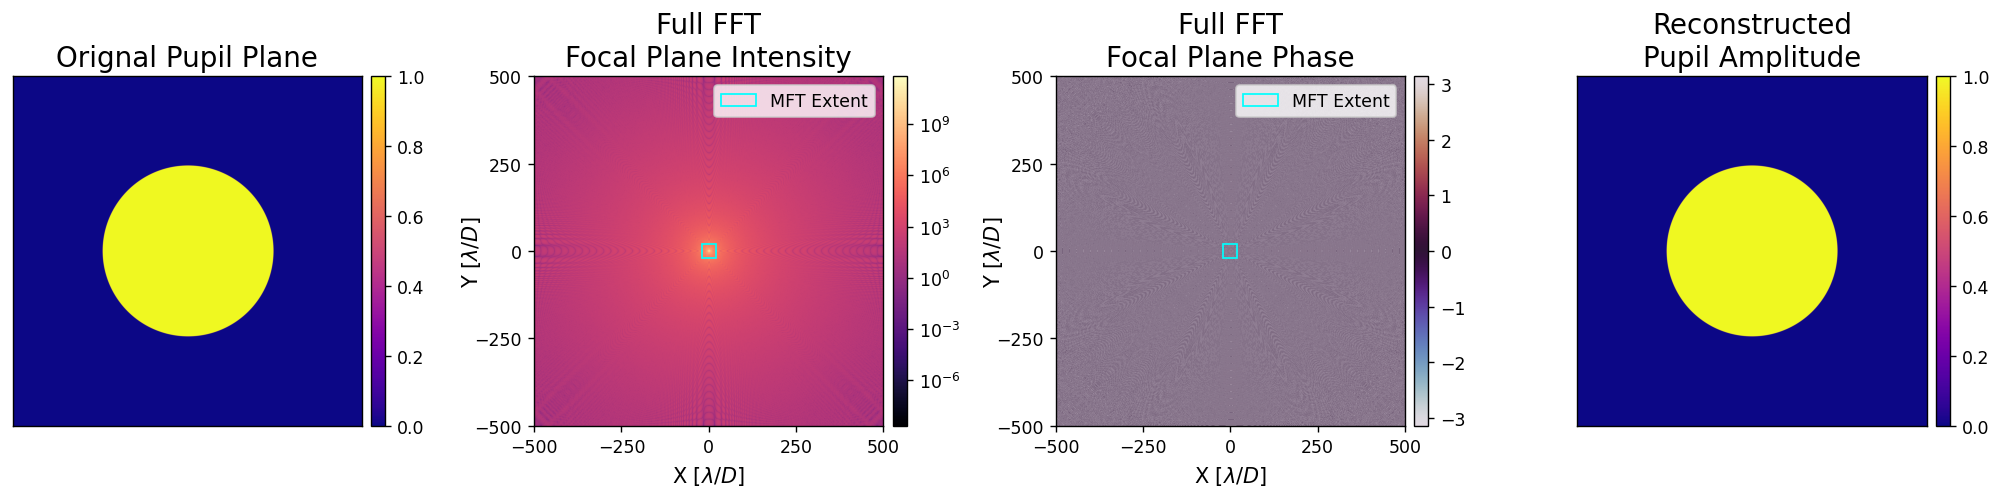

1


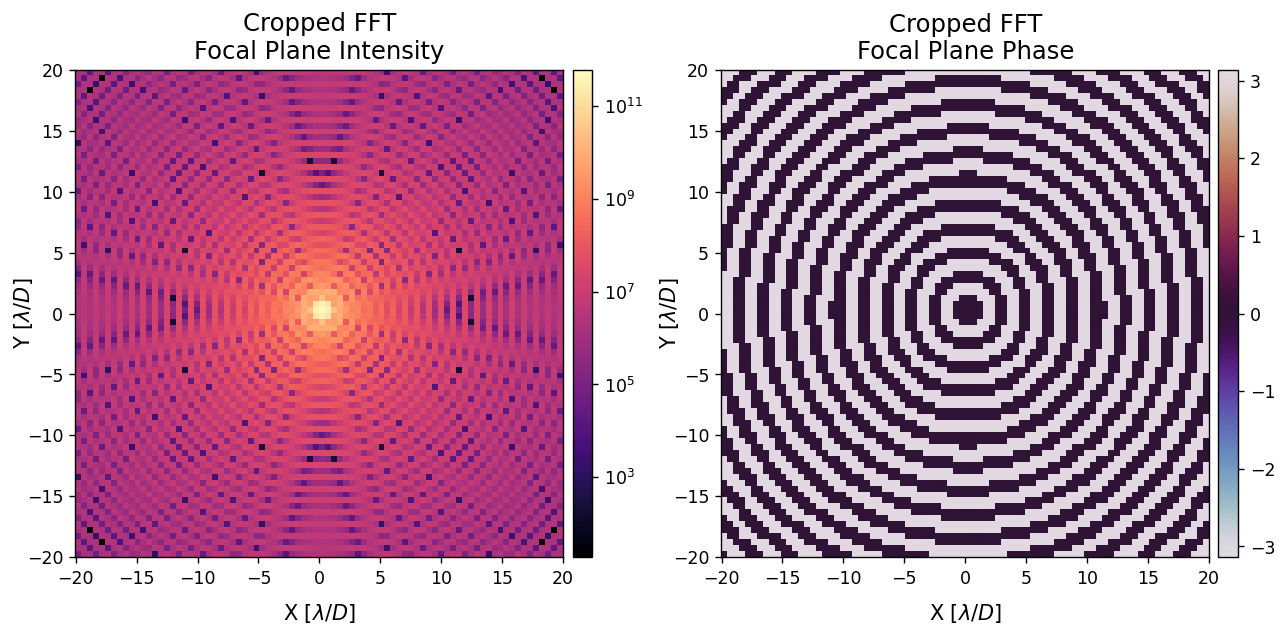

In [3]:
reload(utils)

diam = 10*u.mm
npix = 1000
oversample = 2.048
fp_pxscl = 1/oversample

pwf = poppy.FresnelWavefront(beam_radius=diam/2, npix=npix, oversample=oversample)
ap = poppy.CircularAperture(radius=diam/2, ).get_transmission(pwf)

fpwf_fft = props.fft(ap,)
fp_int = xp.abs(fpwf_fft)**2
fp_phs = xp.angle(fpwf_fft)

reconstructed_pupil = xp.abs(props.ifft(fpwf_fft))

fp_ext = 500
fp_ticks = np.arange(-fp_ext, fp_ext + 0.01, 250)

fig, axs = utils.imshow(
    [ap, fp_int, fp_phs, reconstructed_pupil],
    titles=['Orignal Pupil Plane', 'Full FFT\nFocal Plane Intensity', 'Full FFT\nFocal Plane Phase', 'Reconstructed\nPupil Amplitude'],
    title_fzs=[16]*4,
    xticks=[[], fp_ticks, fp_ticks, []],
    yticks=[[], fp_ticks, fp_ticks, []],
    pxscls=[1, fp_pxscl, fp_pxscl, 1],
    xlabels=[None, 'X [$\lambda/D$]', 'X [$\lambda/D$]', None],
    ylabels=[None, 'Y [$\lambda/D$]', 'Y [$\lambda/D$]', None],
    xlabel_pads=[None, 5, 5, None],
    ylabel_pads=[None, -5, -5, None],
    label_fzs=[None, 12, 12, None],
    all_patches=[None, 
                 [Rectangle((-20,-20), width=40, height=40, fill=False, color='cyan', label='MFT Extent')],
                 [Rectangle((-20,-20), width=40, height=40, fill=False, color='cyan', label='MFT Extent')],
                 None],
    norms=[None, LogNorm(), None],
    cmaps=['plasma', 'magma', 'twilight', 'plasma'],
    wspace=0.4,
    figsize=(20,5),
    return_fig=True,
)

axs[1].legend()
axs[2].legend()
display(fig)

Next = int(np.round(2*20/fp_pxscl))
fp_ext = 20
fp_ticks = np.arange(-fp_ext, fp_ext + 0.01, 5)

# fp_ext = 160/2 * fp_pxscl
# fp_ticks = np.linspace(-fp_ext, fp_ext, 7)

utils.imshow(
    [fp_int, fp_phs,],
    titles=['Cropped FFT\nFocal Plane Intensity', 'Cropped FFT\nFocal Plane Phase',],
    # npix=[160, 160],
    npix=[Next, Next],
    title_fzs=[14]*4,
    xticks=[fp_ticks, fp_ticks],
    yticks=[fp_ticks, fp_ticks],
    pxscls=[fp_pxscl, fp_pxscl],
    xlabels=['X [$\lambda/D$]', 'X [$\lambda/D$]',],
    ylabels=['Y [$\lambda/D$]', 'Y [$\lambda/D$]',],
    xlabel_pads=[8, 8, None],
    ylabel_pads=[-5, -5, None],
    label_fzs=[12, 12, None],
    norms=[LogNorm(), None],
    cmaps=['magma', 'twilight',],
    wspace=0.25,
    figsize=(12,6),
)

In [73]:
Next

81.92

1


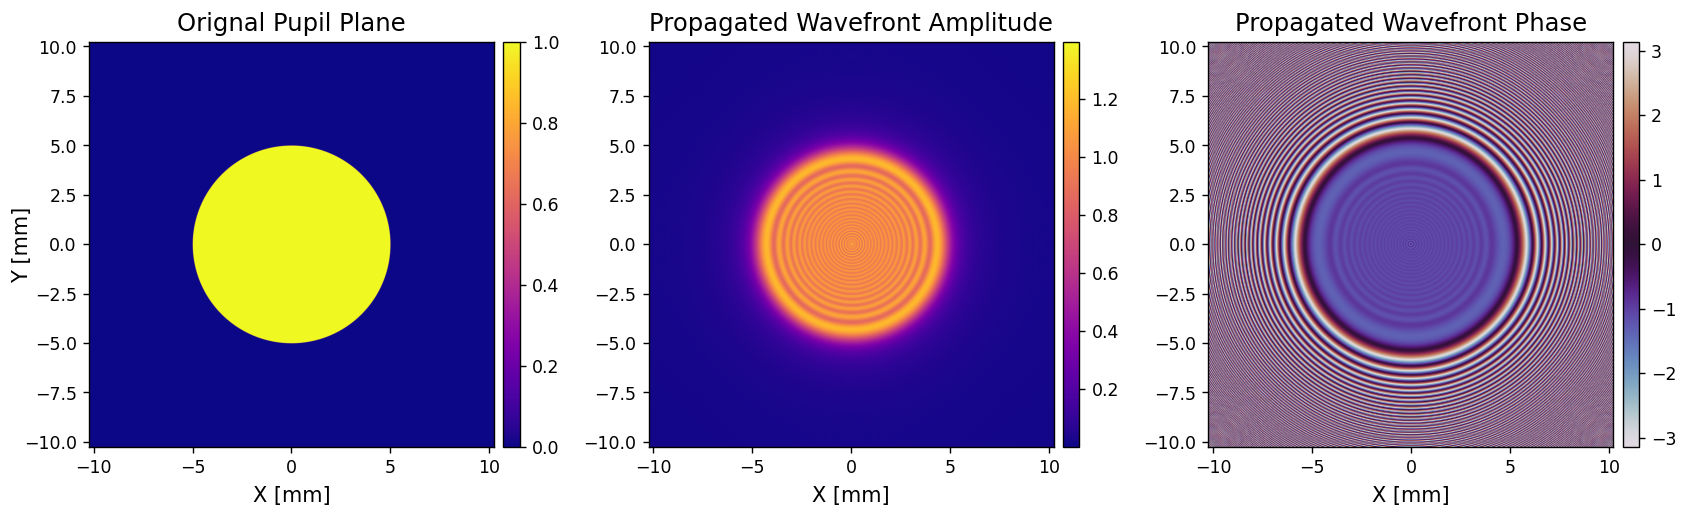

In [10]:
reload(utils)

diam = 10e-3
npix = 1000
pixelscale = diam/npix
oversample = 2.048
d_prop = 1000e-3

pwf = poppy.FresnelWavefront(beam_radius=diam/2*u.m, npix=npix, oversample=oversample)
ap = poppy.CircularAperture(radius=diam/2 * u.m, ).get_transmission(pwf)

as_wf = props.ang_spec(ap, wavelength=633e-9, distance=d_prop, pixelscale=pixelscale)
as_wf_amp = xp.abs(as_wf)
as_wf_phs = xp.angle(as_wf)

fp_ext = 500
fp_ticks = np.arange(-fp_ext, fp_ext + 0.01, 250)

utils.imshow(
    [ap, as_wf_amp, as_wf_phs],
    titles=['Orignal Pupil Plane', 'Propagated Wavefront Amplitude', 'Propagated Wavefront Phase'],
    title_fzs=[14]*4,
    # xticks=[[], fp_ticks, fp_ticks, []],
    # yticks=[[], fp_ticks, fp_ticks, []],
    pxscls=[pixelscale*1000]*3,
    xlabels=['X [mm]', 'X [mm]', 'X [mm]'],
    ylabels=['Y [mm]', None],
    xlabel_pads=[5]*3,
    ylabel_pads=[-5],
    label_fzs=[12]*3,
    # all_patches=[None, 
    #              [Rectangle((-20,-20), width=40, height=40, fill=False, color='cyan', label='MFT Extent')],
    #              [Rectangle((-20,-20), width=40, height=40, fill=False, color='cyan', label='MFT Extent')],
    #              None],
    norms=[None, None, None],
    cmaps=['plasma', 'plasma', 'twilight',],
    wspace=0.3,
    figsize=(16,5),
)

# Time FFTs and MFTs

1024


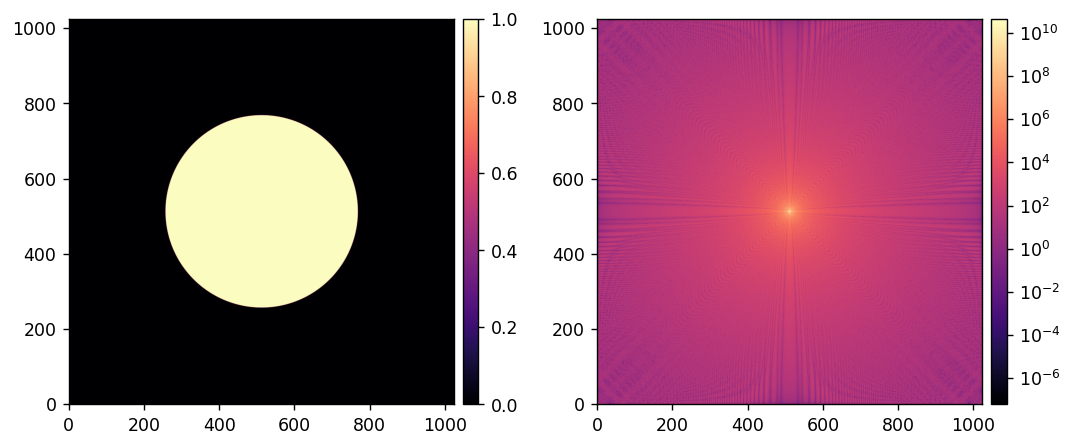

In [6]:
diam = 10e-3
npix = 512
pixelscale = diam/npix
oversample = 2
print(npix*oversample)

pwf = poppy.FresnelWavefront(beam_radius=diam/2*u.m, npix=npix, oversample=oversample)
ap = poppy.CircularAperture(radius=diam/2 * u.m, ).get_transmission(pwf)

fpwf = props.fft(ap)

utils.imshow([ap, xp.abs(fpwf)**2], norms=[None, LogNorm()])

In [11]:
%timeit props.fft(ap)

886 μs ± 572 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [7]:
%timeit props.fft(ap)

18.9 ms ± 26.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [8]:
18.9e-3/130e-6

145.3846153846154

In [9]:
95.5e-3/241e-6

396.2655601659751

In [10]:
388e-3/886e-6

437.9232505643341

1000


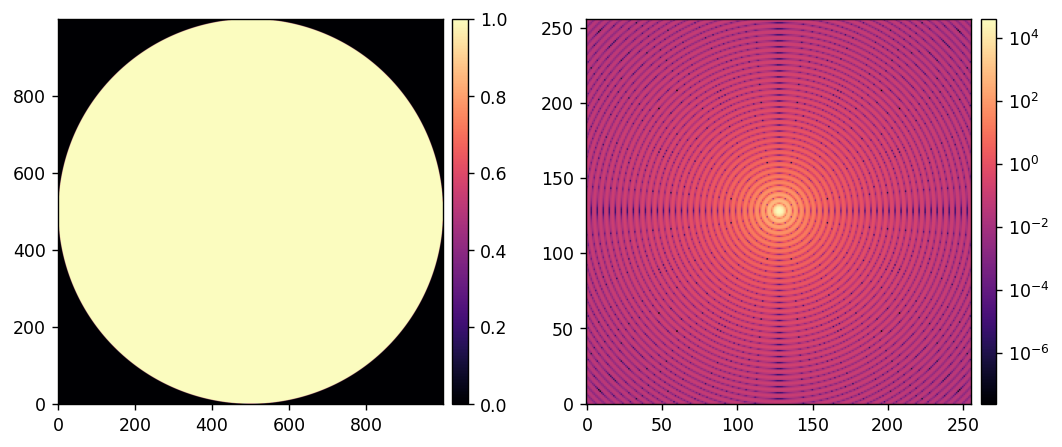

In [2]:
diam = 10e-3
npix = 1000
pixelscale = diam/npix
oversample = 1
print(npix*oversample)

pwf = poppy.FresnelWavefront(beam_radius=diam/2*u.m, npix=npix, oversample=oversample)
ap = poppy.CircularAperture(radius=diam/2 * u.m, ).get_transmission(pwf)

fpwf = props.mft_forward(ap, 1000, 256, 0.25)

utils.imshow([ap, xp.abs(fpwf)**2], norms=[None, LogNorm()])

In [3]:
%timeit props.mft_forward(ap, 1000, 256, 0.25)

232 μs ± 575 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [14]:
%timeit props.mft_forward(ap, 1000, 256, 0.25)

47 ms ± 87 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [4]:
47e-3/232e-6

202.58620689655172

# Make POPPY Lyot coronagraph and generate figures.

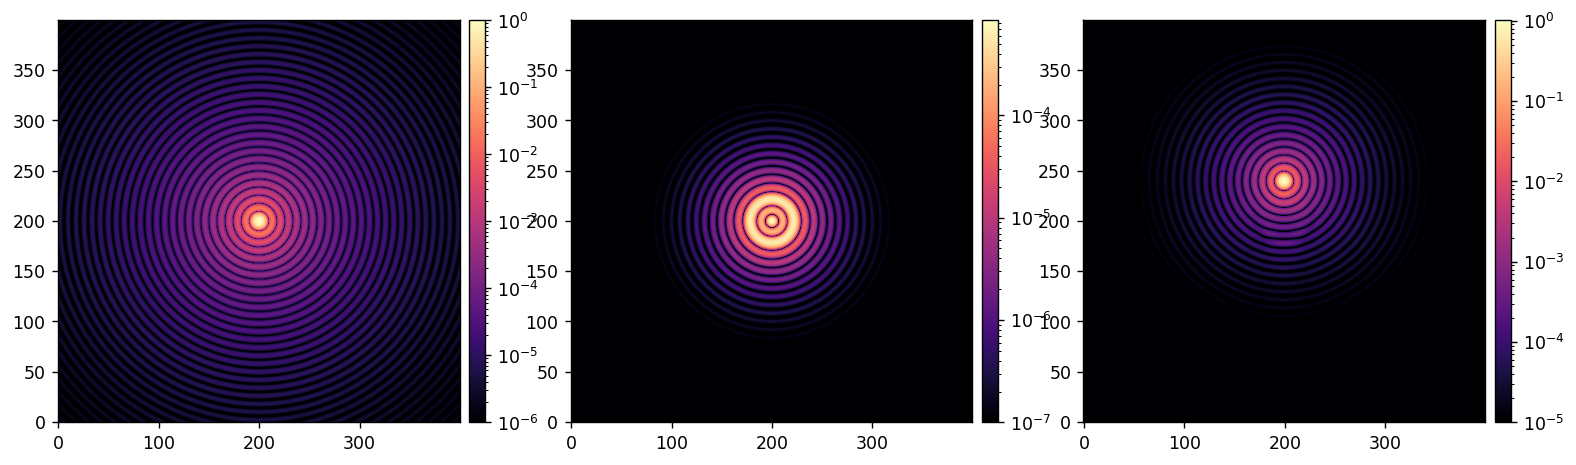

In [2]:
wavelength = 650e-9
diameter = 6.5
lyot_diam = 5.5

as_per_lamD = (wavelength/diameter * u.radian).to(u.arcsec)
as_per_lamDls = (wavelength/lyot_diam * u.radian).to(u.arcsec)
occ_rad = 3.24*as_per_lamD

pixelscale = 2*as_per_lamDls.value 
fov = 50*as_per_lamDls.value
npix = 256
oversample = 16

osys = poppy.OpticalSystem("test", npix=npix, oversample=oversample)
osys.add_pupil( poppy.CircularAperture(radius=diameter/2, name='Entrance Pupil'),)
osys.add_image( poppy.ScalarTransmission(name='At Focal Plane Mask') )
# osys.add_image( poppy.CircularOcculter(radius = occ_rad, name='After Lyot Occulter') )
osys.add_pupil( poppy.ScalarTransmission(name='Lyot Pupil'))
osys.add_pupil( poppy.CircularAperture(radius=lyot_diam/2, name='Lyot Stop (pupil)'))
osys.add_detector(pixelscale=pixelscale, fov_arcsec=fov, name='Camera Focal Plane')
_, wfs_unocc = osys.calc_psf(wavelength=wavelength*u.m, normalize='none', return_intermediates=True)
unocc_psf = wfs_unocc[-1].intensity
Imax_ref = xp.max(unocc_psf)
unocc_psf /= Imax_ref

osys = poppy.OpticalSystem("test", npix=npix, oversample=oversample)
osys.add_pupil( poppy.CircularAperture(radius=diameter/2, name='Entrance Pupil'),)
osys.add_image( poppy.ScalarTransmission(name='At Focal Plane Mask') )
osys.add_image( poppy.CircularOcculter(radius = occ_rad, name='After Lyot Occulter') )
osys.add_pupil( poppy.ScalarTransmission(name='Lyot Pupil'))
osys.add_pupil( poppy.CircularAperture(radius=lyot_diam/2, name='Lyot Stop (pupil)'))
osys.add_detector(pixelscale=pixelscale, fov_arcsec=fov, name='Camera Focal Plane')
_, wfs_coro = osys.calc_psf(wavelength=wavelength*u.m, normalize='none', return_intermediates=True)
coro_im = wfs_coro[-1].intensity / Imax_ref

osys = poppy.OpticalSystem("test", npix=npix, oversample=oversample)
osys.add_pupil( poppy.CircularAperture(radius=diameter/2, name='Entrance Pupil'),)
osys.add_image( poppy.ScalarTransmission(name='At Focal Plane Mask') )
osys.add_image( poppy.CircularOcculter(radius = occ_rad, name='After Lyot Occulter') )
osys.add_pupil( poppy.ScalarTransmission(name='Lyot Pupil'))
osys.add_pupil( poppy.CircularAperture(radius=lyot_diam/2, name='Lyot Stop (pupil)'))
osys.add_detector(pixelscale=pixelscale, fov_arcsec=fov, name='Camera Focal Plane')

osys.source_offset_theta = 0
osys.source_offset_r = -5*as_per_lamDls
_, wfs_offax = osys.calc_psf(wavelength=wavelength*u.m, normalize='none', return_intermediates=True)
offax_psf = xp.flipud(wfs_offax[-1].intensity) / Imax_ref

planet_contrast = 1e-4
total_nom_im = unocc_psf + planet_contrast * offax_psf
total_coro_im = coro_im + planet_contrast * offax_psf

utils.imshow(
    [unocc_psf, coro_im, offax_psf],
    norms=[LogNorm(1e-6), LogNorm(1e-7), LogNorm(1e-5)],
    # figsize=(20,5), 
)

In [35]:
(650e-9/6.5 * u.radian).to(u.arcsec)

<Quantity 0.02062648 arcsec>

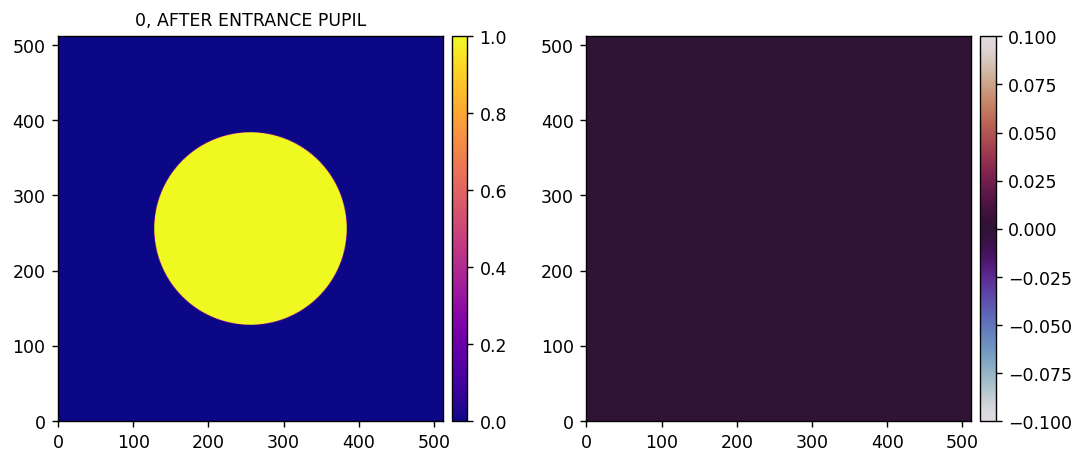

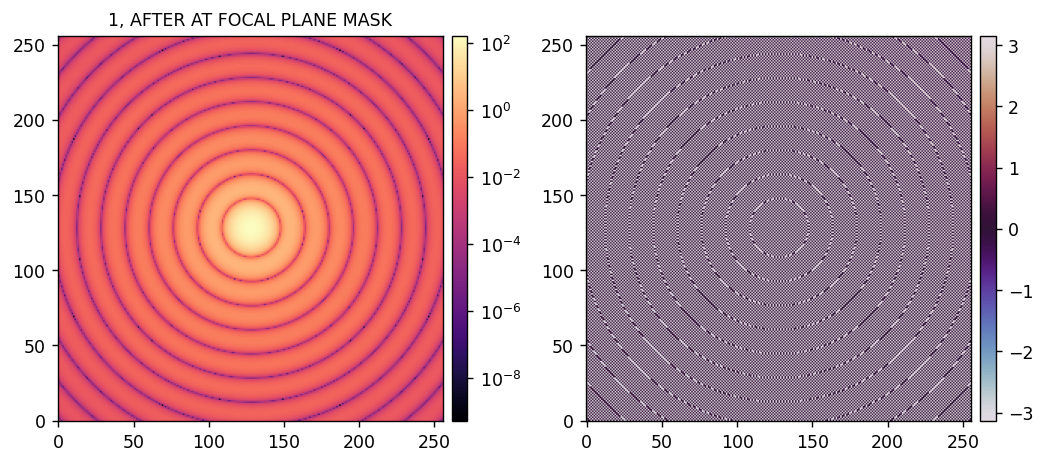

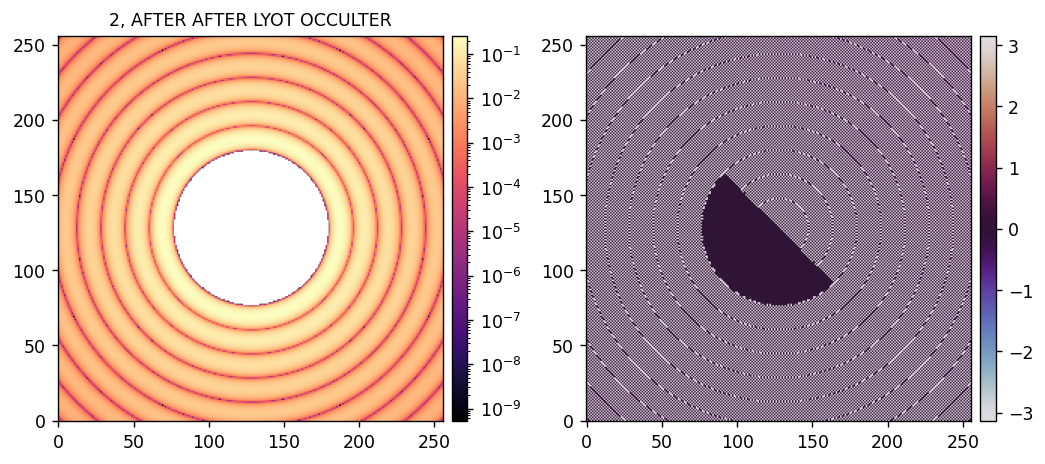

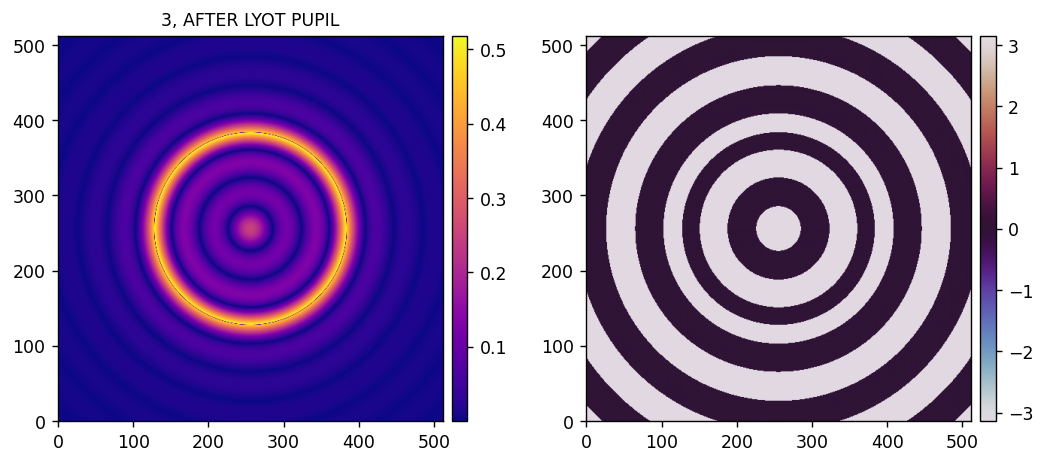

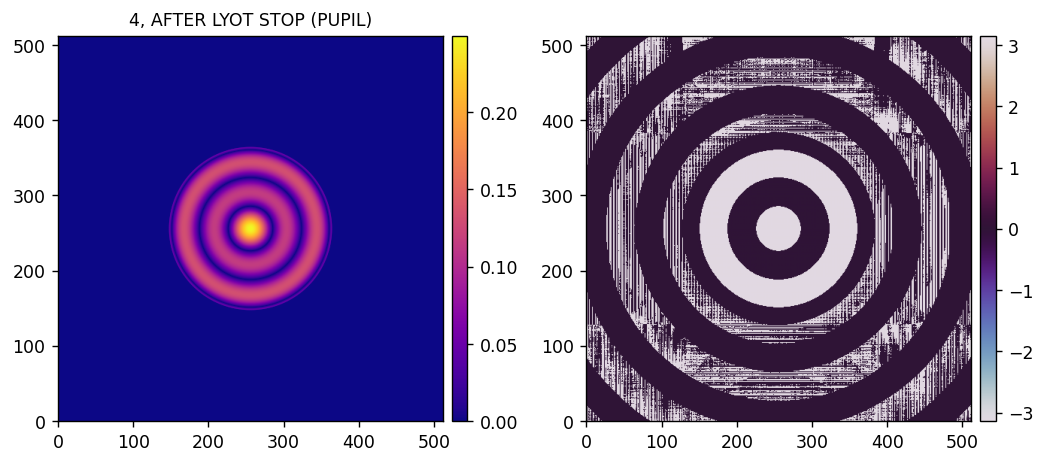

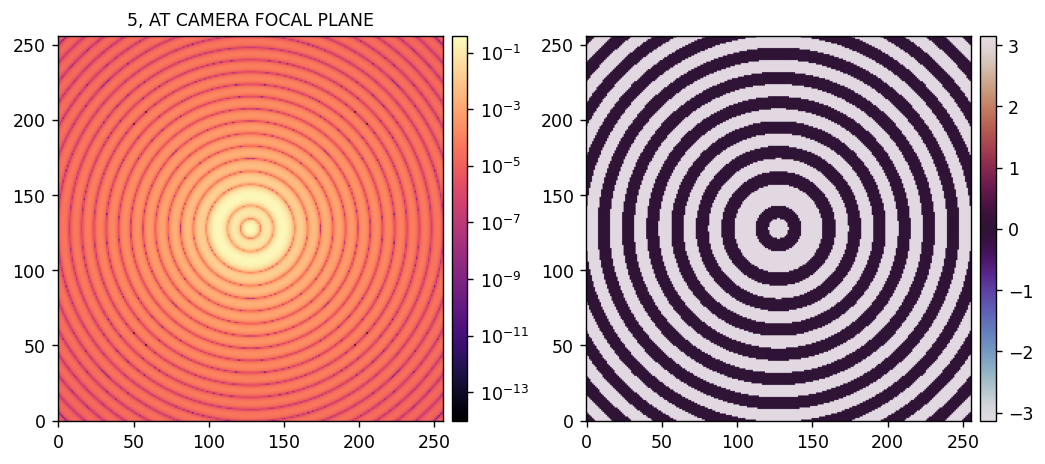

In [3]:
for i in range(len(wfs_coro)):
    if 'pupil' in wfs_coro[i].location.lower():
        utils.imshow(
            [wfs_coro[i].amplitude, wfs_coro[i].phase],
            titles=[f'{i:d}, {wfs_coro[i].location.upper()}'],
            cmaps=['plasma', 'twilight'],
            npix=[2*npix]*2,
        )
    else:
        utils.imshow(
            [wfs_coro[i].intensity, wfs_coro[i].phase],
            titles=[f'{i:d}, {wfs_coro[i].location.upper()}'],
            cmaps=['magma', 'twilight'],
            npix=[256]*2,
            norms=[LogNorm(), None],
        )

In [10]:
pixelscale /as_per_lamDls /oversample

<Quantity 0.125 1 / arcsec>

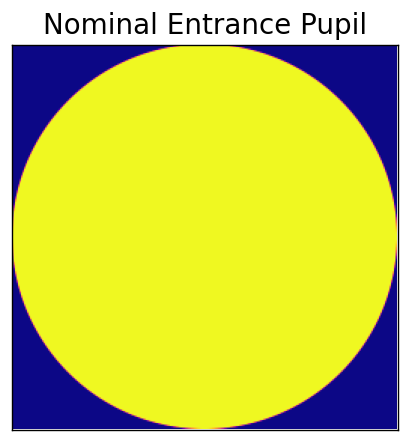

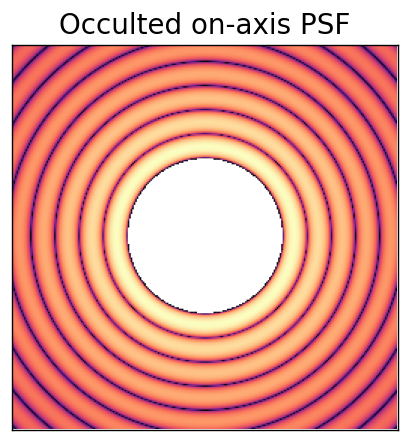

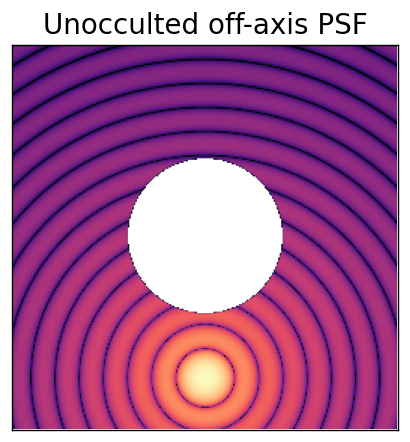

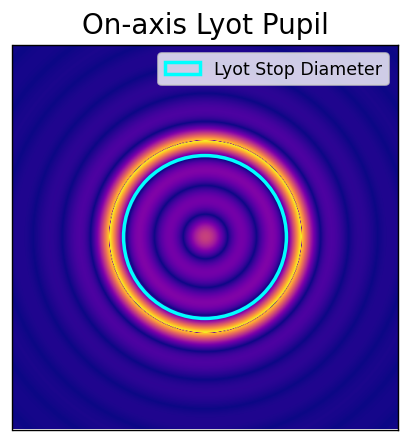

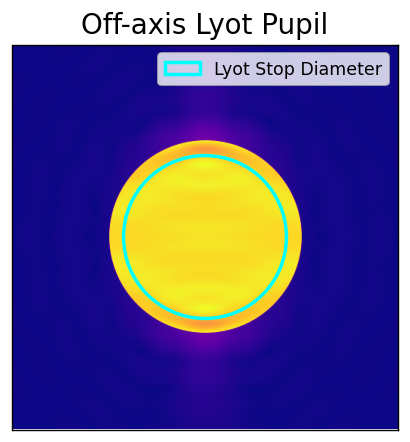

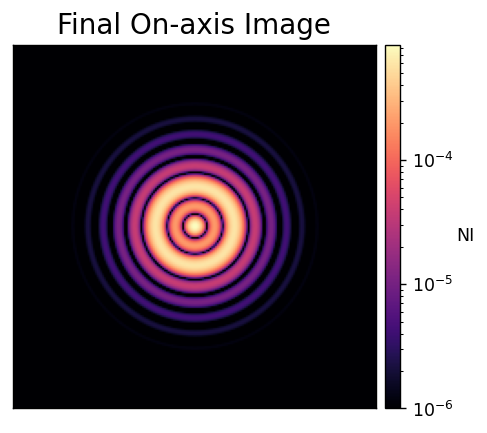

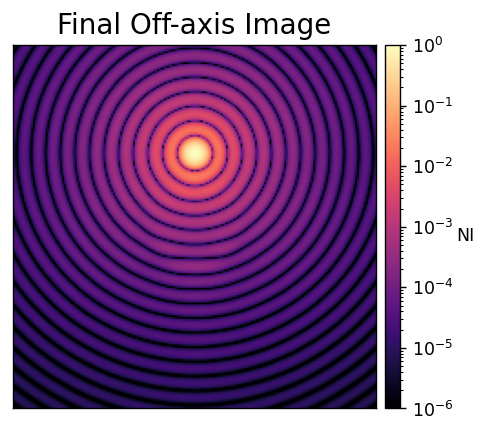

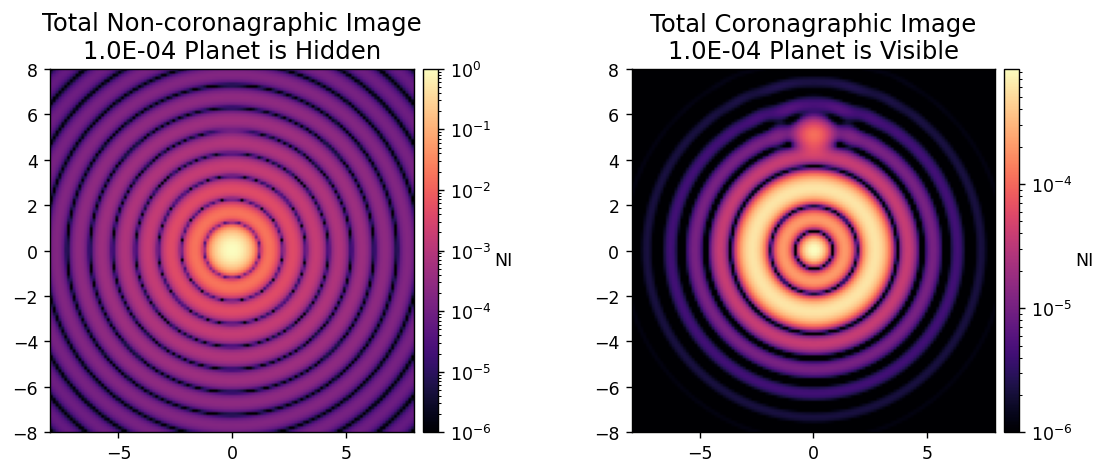

In [17]:
reload(utils)

utils.imshow(
    [wfs_coro[0].amplitude],
    titles=['Nominal Entrance Pupil'],
    title_fzs=[16],
    cmaps=['plasma'],
    show_cbars=[False],
    npix=[1*npix],
    xticks=[[]],
    yticks=[[]],
)

utils.imshow(
    [wfs_coro[2].intensity],
    titles=['Occulted on-axis PSF'],
    title_fzs=[16],
    cmaps=['magma'],
    show_cbars=[False],
    norms=[LogNorm(1e-5)],
    npix=[256],
    xticks=[[]],
    yticks=[[]],
)

utils.imshow(
    [wfs_offax[2].intensity],
    titles=['Unocculted off-axis PSF'],
    title_fzs=[16],
    cmaps=['magma'],
    show_cbars=[False],
    norms=[LogNorm(1e-5)],
    npix=[256],
    xticks=[[]],
    yticks=[[]],
)

fig,axs = utils.imshow(
    [wfs_coro[3].amplitude],
    titles=['On-axis Lyot Pupil'],
    title_fzs=[16],
    cmaps=['plasma'],
    show_cbars=[False],
    # norms=[LogNorm(1e-5)],
    npix=[2*npix],
    xticks=[[]],
    yticks=[[]],
    pxscls=[diameter/npix],
    all_patches=[
        [Circle((0,0), lyot_diam/2, fill=False, color='cyan', linewidth=2, label='Lyot Stop Diameter')]
    ],
    return_fig=True,
)
axs.legend()
display(fig)

fig,axs = utils.imshow(
    [wfs_offax[3].amplitude],
    titles=['Off-axis Lyot Pupil'],
    title_fzs=[16],
    cmaps=['plasma'],
    show_cbars=[False],
    # norms=[LogNorm(1e-5)],
    npix=[2*npix],
    xticks=[[]],
    yticks=[[]],
    pxscls=[diameter/npix],
    all_patches=[
        [Circle((0,0), lyot_diam/2, fill=False, color='cyan', linewidth=2, label='Lyot Stop Diameter')]
    ],
    return_fig=True,
)
axs.legend()
display(fig)

utils.imshow(
    [wfs_coro[-1].intensity/ Imax_ref],
    titles=['Final On-axis Image'],
    title_fzs=[16],
    cmaps=['magma'],
    cbar_labels=['NI']*2,
    show_cbars=[True],
    norms=[LogNorm(1e-6)],
    npix=[200],
    xticks=[[]],
    yticks=[[]],
)

utils.imshow(
    [offax_psf],
    titles=['Final Off-axis Image'],
    title_fzs=[16],
    cmaps=['magma'],
    cbar_labels=['NI']*2,
    show_cbars=[True],
    norms=[LogNorm(1e-6)],
    npix=[200],
    xticks=[[]],
    yticks=[[]],
)

utils.imshow(
    [total_nom_im, total_coro_im],
    titles=[f'Total Non-coronagraphic Image\n{planet_contrast:.1E} Planet is Hidden', 
            f'Total Coronagraphic Image\n{planet_contrast:.1E} Planet is Visible'],
    title_fzs=[14]*2,
    npix=[128]*2,
    cbar_labels=['NI']*2,
    norms=[LogNorm(1e-6), LogNorm(1e-6)],
    pxscls=[1/8]*2,
    # xticks=[[], []],
    # yticks=[[], []],
    wspace=0.5,
)

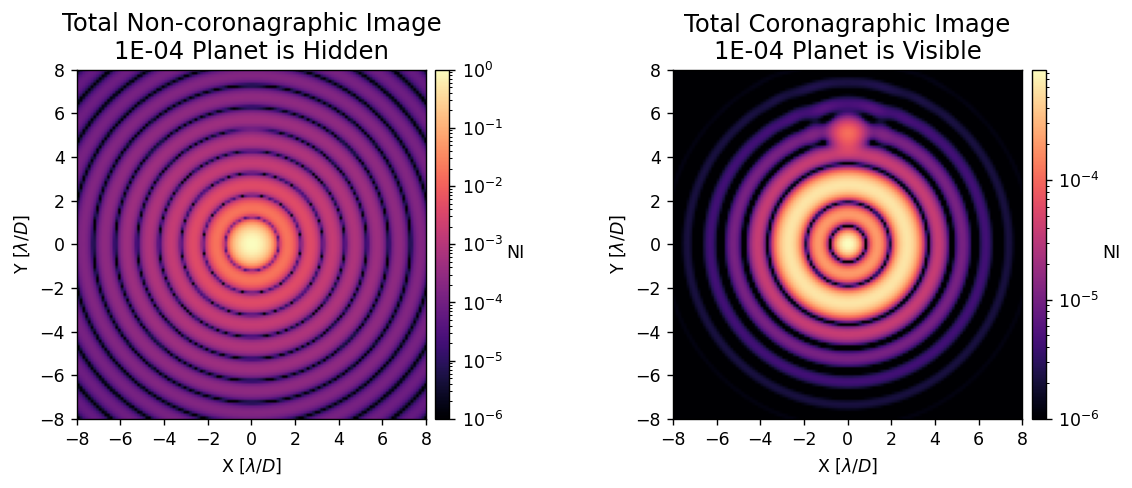

In [18]:
ticks = np.arange(-8, 8.01, 2)
utils.imshow(
    [total_nom_im, total_coro_im],
    titles=[f'Total Non-coronagraphic Image\n{planet_contrast:.0E} Planet is Hidden', 
            f'Total Coronagraphic Image\n{planet_contrast:.0E} Planet is Visible'],
    title_fzs=[14]*2,
    npix=[128]*2,
    cbar_labels=['NI']*2,
    norms=[LogNorm(1e-6), LogNorm(1e-6)],
    pxscls=[1/8]*2,
    xticks=[ticks]*2,
    yticks=[ticks]*2,
    xlabels=['X [$\lambda/D$]']*2,
    ylabels=['Y [$\lambda/D$]']*2,
    wspace=0.6,
)